<a href="https://colab.research.google.com/github/MahinourAbdelgawad/Plant-Disease-Detection/blob/main/plant_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plant Species and Disease Detection
Possible scopes:
- Predict species
- Predict diseased or healthy
- Predict diseased or healthy given species
- Predict disease
- Predict disease given species

Methods?
- Classical CV: Can predict diseased vs. healthy by detecting color shifts (green vs brown spots) and leaf shapes, but completely blind to the small differences between specific diseases or plant species
- Classical ML: Can predict diseased vs. healthy, predict species, and predict disease given species if a human manually calculates and inputs the mathematical features (like texture math or spot sizes)
- Deep Learning: Can do all scopes

Possible paths:
- Predict diseased or healthy using classical CV and then classical ML and then DL and compare

In [57]:
# FOR RUNNING LOCALLY
! pip install matplotlib opencv-python numpy seaborn pandas tqdm scikit-learn kagglehub scikit-image


  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 582.0 kB/s eta 0:00:00m eta 0:00:010:00:01
Using cached imageio-2.37.3-py3-none-any.whl (317 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.1/267.1 kB 722.1 kB/s eta 0:00:00 kB/s eta 0:00:01:01


### STEP 0: Load dataset, examine data, and preprocess

In [47]:
import matplotlib.pyplot as plt
import cv2 as cv
import pandas as pd
import seaborn as sns
import numpy as np

In [48]:
import os
from google.colab import userdata

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
#LOCAL VERSION
! pip install python-dotenv
import os
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get('KAGGLE_API_TOKEN'):
    print("Error: Could not find 'KAGGLE_API_TOKEN'")

In [ ]:
! pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("riteshmaurya86/cleaned-plant-disease-image-dataset")

print("Dataset downloaded to:", path)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 465.8 kB/s eta 0:00:001m992.2 kB/s eta 0:00:01
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 620.5 kB/s eta 0:00:00MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.5 MB/s eta 0:00:00
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.6.17-py3-none-any.whl.metadata (2.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.8/243.8 kB 1.8 MB/s eta 0:00:002.4 MB/s eta 0:00:01
Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (807 kB)
Using cached requests-2.34.2-py3-none-a

/media/mahi/Shared/AUC/Semesters/6.5- Summer 2026/Fundamentals of Computer Vision/Project/Plant-Disease-Detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.34G/1.34G [21:26<00:00, 1.12MB/s]

Extracting files...


Dataset downloaded to: /home/mahi/.cache/kagglehub/datasets/riteshmaurya86/cleaned-plant-disease-image-dataset/versions/1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/PlantDetection'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
# LOCAL VERSION
import os
OUTPUT_DIR = os.path.expanduser('outputs') 
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
# check out the dataset
import os

DATA_DIR = os.path.join(path, 'data')
TRAIN_DIR = os.path.join(DATA_DIR, 'train')

classes = sorted(os.listdir(TRAIN_DIR))
print(f"Number of classes: {len(classes)}")
for c in classes:
    n = len(os.listdir(os.path.join(TRAIN_DIR, c)))
    print(f"{c}: {n} images")

Number of classes: 38
Apple___Apple_scab: 2016 images
Apple___Black_rot: 1987 images
Apple___Cedar_apple_rust: 1760 images
Apple___healthy: 2008 images
Blueberry___healthy: 1816 images
Cherry_(including_sour)___Powdery_mildew: 1683 images
Cherry_(including_sour)___healthy: 1826 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642 images
Corn_(maize)___Common_rust_: 1907 images
Corn_(maize)___Northern_Leaf_Blight: 1908 images
Corn_(maize)___healthy: 1859 images
Grape___Black_rot: 1888 images
Grape___Esca_(Black_Measles): 1920 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722 images
Grape___healthy: 1692 images
Orange___Haunglongbing_(Citrus_greening): 2010 images
Peach___Bacterial_spot: 1838 images
Peach___healthy: 1728 images
Pepper,_bell___Bacterial_spot: 1913 images
Pepper,_bell___healthy: 1988 images
Potato___Early_blight: 1939 images
Potato___Late_blight: 1939 images
Potato___healthy: 1824 images
Raspberry___healthy: 1781 images
Soybean___healthy: 2022 images
Squas

In [ ]:
# visualize some samples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_classes = classes[:8]

for ax, c in zip(axes.flat, sample_classes):
    img_name = os.listdir(os.path.join(TRAIN_DIR, c))[0]
    img = cv.imread(os.path.join(TRAIN_DIR, c, img_name))
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(c, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# dataset summary
import os
data_list = []
for c in classes:
    num_images = len(os.listdir(os.path.join(TRAIN_DIR, c)))


    if "___" in c:
        plant, disease = c.split("___")
    else:
        plant, disease = c, "Unknown"

    data_list.append({
        'Folder_Name': c,
        'Plant': plant.replace('_', ' '),
        'Condition': disease.replace('_', ' '),
        'Image_Count': num_images
    })

df = pd.DataFrame(data_list)

total_images = df['Image_Count'].sum()
unique_plants = df['Plant'].nunique()
unique_conditions = df[df['Condition'] != 'healthy']['Condition'].nunique()

print("="*40)
print(f"DATASET SUMMARY")
print("="*40)
print(f"Total Images: {total_images:,}")
print(f"Unique Plants: {unique_plants} {df['Plant'].unique().tolist()}")
print(f"Unique Diseases: {unique_conditions}")
print(f"Average images/class: {df['Image_Count'].mean():.1f}")
print("="*40)

In [ ]:
# experimemt with preprocessing
class_index = 0
image_index = 777

canny_threshold1 = 40
canny_threshold2 = 100

img = cv.imread(os.path.join(TRAIN_DIR, classes[class_index], os.listdir(os.path.join(TRAIN_DIR, classes[class_index]))[image_index]))

img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Grayscale
gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

# Gaussian filter
blurred = cv.GaussianBlur(gray, (5, 5), 0)

# Canny edge detectio
edges = cv.Canny(blurred, threshold1=canny_threshold1, threshold2=canny_threshold2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Original', 'Grayscale', 'Filtered (Gaussian Blur)', 'Edges (Canny)']
imgs = [img, gray, blurred, edges]
cmaps = [None, 'gray', 'gray', 'gray']
for ax, im, t, cm in zip(axes, imgs, titles, cmaps):
    ax.imshow(im, cmap=cm)
    ax.set_title(t)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def preprocess(path):
  #TODO: come back to this, what preprocessing will we really need????
  img = cv.imread(path)
  img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
  # img = cv.resize(img, size)

  canny_threshold1 = 40
  canny_threshold2 = 100

  gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
  blurred = cv.GaussianBlur(gray, (5, 5), 0)
  edges = cv.Canny(blurred, canny_threshold1, canny_threshold2)

  return img, gray, blurred, edges

## GOAL 1: DISEASED VS HEALTHY

In [ ]:
# HELPER FUNCTION FOR ALL 3 APPROACHES
def get_label(class_name): # retrieve label for each class for training (healthy or diseases)
    return "healthy" if "healthy" in class_name.lower() else "diseased"

### Step 1: Classical CV only
Predict if a leaf is diseased or healthy based on a rule-based heuristic and a threshold on a visual measurement (color).
Built on the ratio of green color in a lead (higher brown/yellow patches = diseased)
THis is based only on color and does not consider curving, etc..

In [ ]:
# First segment the leaf so we can exlude the background
def segment_leaf(image): 
    """
    returns MASK not the leaf image
    """  
    # convert to hsv format to make the diff between leaf and background more obvious
    hsv_image = cv.cvtColor(image, cv.COLOR_RGB2HSV)

    lower_green = np.array([25,0,20]) #Array with lower bound of acceptable green color values
    upper_green = np.array([100,255,255]) #Array with upper bound of acceptable green color values
    
    leaf_mask = cv.inRange(hsv_image, lower_green, upper_green) #Removing unwanted colors on the HSV image

    #Putting the remaining pixels back on the RGB image using bitwise and
    segmented_leaf = cv.bitwise_and(image, image, mask=leaf_mask) 
    # return segmented_leaf

    # This worked well but there are missing spots (e.g. the diseased spots that arent green)
    # to fix this: isolate the spots and then combine both masks
    lower_brown = np.array([10,0,10]) #Array with lower bound of acceptable brown color values
    upper_brown = np.array([30,255,255]) #Array with upper bound of acceptable brown color values

    spot_mask = cv.inRange(hsv_image, lower_brown, upper_brown) #Removing unwanted colors on the HSV image

    spots_leaf = cv.bitwise_and(image, image, mask=spot_mask) 
    # return spots_leaf

    # now combine both
    final_mask = leaf_mask + spot_mask
    final_leaf = cv.bitwise_and(image, image, mask=final_mask) 
    # return final_leaf
    return final_mask

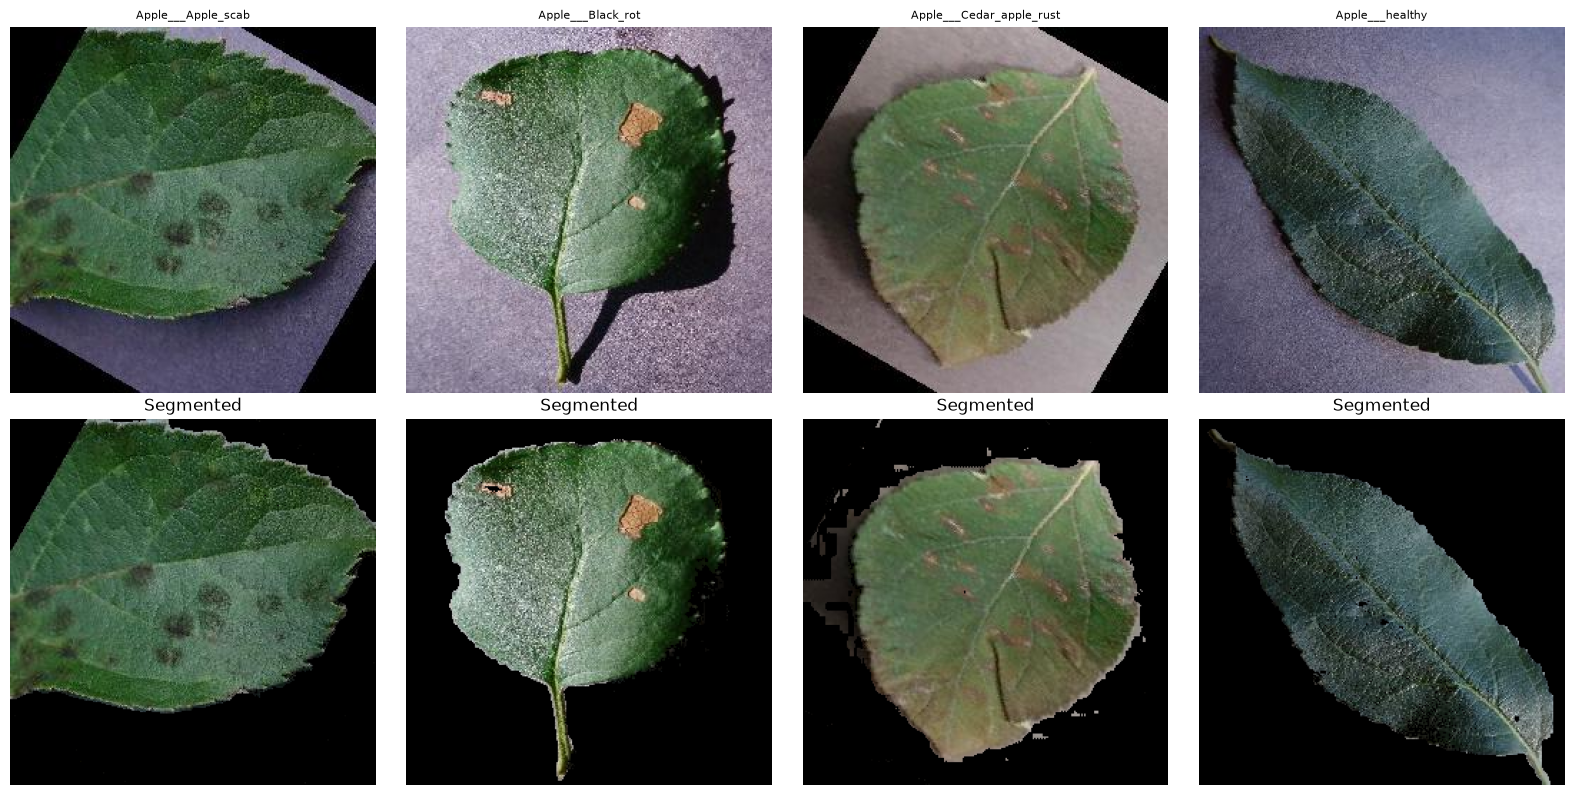

In [ ]:
# test segmentation on sample
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample = classes[:4]
for i, c in enumerate(sample):
    img = cv.imread(os.path.join(TRAIN_DIR, c, os.listdir(os.path.join(TRAIN_DIR, c))[0]))
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    segmented = cv.bitwise_and(img, img, mask=(segment_leaf(img)))

    axes[0, i].imshow(img); axes[0, i].set_title(c, fontsize=8); axes[0, i].axis('off')
    axes[1, i].imshow(segmented, cmap='gray'); axes[1, i].set_title('Segmented'); axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def green_ratio(img):
    mask = segment_leaf(img)
    leaf_pixels = mask > 0
    total_leaf = leaf_pixels.sum()
    if total_leaf == 0:
        return 0.0  # fallback if segmentation fails on this image
    
    hsv = cv.cvtColor(img, cv.COLOR_RGB2HSV) #convert to hsv for easier color segmentation (focus on green hue)
    # green ranges: OpenCV (0–179 scale): Hue: 40–70, Saturation: 50–255, Value: 50–255
    #TODO: experiment with ranges
    lower_green = (25, 0, 20)
    upper_green = (100, 255, 255)

    green_mask = cv.inRange(hsv, lower_green, upper_green) #create mask of pixels in the green range (255 = in range, 0 = not)
    green_in_leaf = (green_mask > 0) & leaf_pixels

    return green_in_leaf.sum() / total_leaf


In [ ]:
# test ratio function on a sample + select threshold
sample_ratios = {'healthy': [], 'diseased': []}
for c in classes:
    label = get_label(c)
    files = os.listdir(os.path.join(TRAIN_DIR, c))[:30]  # 30 samples per class for  now

    for f in files:
        img = cv.imread(os.path.join(TRAIN_DIR, c, f))
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        sample_ratios[label].append(green_ratio(img))


print("Healthy median green ratio:", np.median(sample_ratios['healthy']))
print("Diseased median green ratio:", np.median(sample_ratios['diseased']))

# MEDIANS FOR 30 SAMPLES PER CLASS:
# Healthy median green ratio: 0.9682909721863244
# Diseased median green ratio: 0.9132242900342824
# FOR 60:
# Healthy median green ratio: 0.9685127178923935
# Diseased median green ratio: 0.9132812400890336
# FOR 100:
# Healthy median green ratio: 0.9696004323680074
# Diseased median green ratio: 0.9125768464871518
# *SELECTED THRESHOLD: 0.42*

Healthy median green ratio: 0.9682909721863244
Diseased median green ratio: 0.9132242900342824


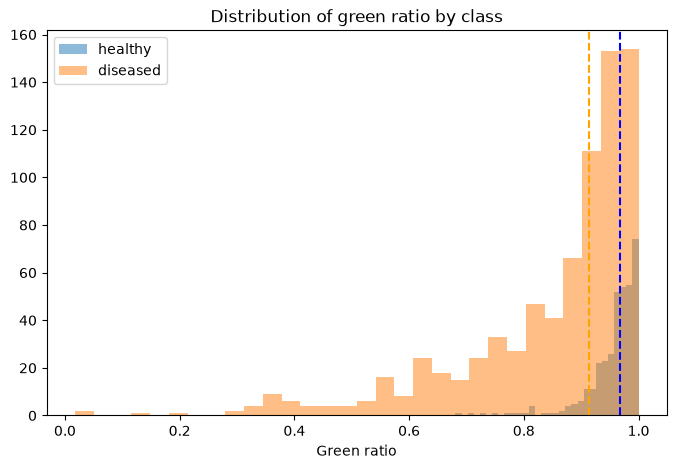

In [ ]:
# visualize distribution
plt.figure(figsize=(8,5))
plt.hist(sample_ratios['healthy'], bins=30, alpha=0.5, label='healthy')
plt.hist(sample_ratios['diseased'], bins=30, alpha=0.5, label='diseased')
plt.axvline(np.median(sample_ratios['healthy']), color='blue', linestyle='--')
plt.axvline(np.median(sample_ratios['diseased']), color='orange', linestyle='--')
plt.legend()
plt.xlabel('Green ratio')
plt.title('Distribution of green ratio by class')
plt.show()

In [ ]:
# pick threshold
#TODO: revise this??
from sklearn.metrics import accuracy_score

all_ratios = sample_ratios['healthy'] + sample_ratios['diseased']
all_labels = ['healthy']*len(sample_ratios['healthy']) + ['diseased']*len(sample_ratios['diseased'])

best_threshold, best_acc = 0, 0
for t in np.arange(0.80, 0.99, 0.005):
    preds = ['healthy' if r >= t else 'diseased' for r in all_ratios]
    acc = accuracy_score(all_labels, preds)
    if acc > best_acc:
        best_acc, best_threshold = acc, t

print(f"Best threshold: {best_threshold:.3f}, calibration accuracy: {best_acc:.3f}")

Best threshold: 0.980, calibration accuracy: 0.714


In [ ]:
# test selected threshold on a random sample
import random
import pandas as pd

# grab a fresh sample, different images than your calibration set
eval_results = []
for c in classes:
    label = get_label(c)
    files = os.listdir(os.path.join(TRAIN_DIR, c))
    sample_files = files[100:150]  # different subset

    for f in sample_files:
        img = cv.imread(os.path.join(TRAIN_DIR, c, f))
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        ratio = green_ratio(img)
        pred = "healthy" if ratio >= best_threshold else "diseased"
        eval_results.append({'true': label, 'pred': pred})

df_eval = pd.DataFrame(eval_results)
print(accuracy_score(df_eval['true'], df_eval['pred']))

0.7105263157894737


In [ ]:
def classical_cv_predict(img, best_threshold = 0.980):
    return "healthy" if green_ratio(img) >= best_threshold else "diseased"

In [ ]:
# RUN! 
# run classical cv predictor on full dataset and save results
import pandas as pd
import time
from tqdm import tqdm

threshold = best_threshold

results = []
start_time = time.time()
total_expected = sum(len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes)

print(f"Expected total images to process: {total_expected}")

processed_count = 0
for c in classes:
    label = get_label(c)
    class_dir = os.path.join(TRAIN_DIR, c)
    files = os.listdir(class_dir)

    class_start = time.time()
    for f in tqdm(files, desc=c, leave=False):  # progress bar perclass
        img = cv.imread(os.path.join(class_dir, f))
        if img is None:
            print(f"Failed to read: {os.path.join(class_dir, f)}")
            continue
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

        ratio = green_ratio(img)
        pred = "healthy" if ratio >= threshold else "diseased"
        results.append({
            'class': c,
            'file': f,
            'true_label': label,
            'green_ratio': ratio,
            'pred_label': pred,
            'correct': pred == label
        })
        processed_count += 1

    class_time = time.time() - class_start
    print(f"✓ {c}: {len(files)} images in {class_time:.1f}s ({len(files)/class_time:.1f} img/s)")

total_time = time.time() - start_time
print(f"\nDone. Processed {processed_count}/{total_expected} images in {total_time/60:.1f} minutes.")

df_cv = pd.DataFrame(results)
print(f"Rows in final dataframe: {len(df_cv)}")

# sanity check: did we actually process everything?
assert len(df_cv) == total_expected, f"MISMATCH: expected {total_expected}, got {len(df_cv)}"
assert processed_count == total_expected, "Some images were skipped (check warnings above)"

df_cv.to_csv(os.path.join(OUTPUT_DIR, 'classical_cv_predictions.csv'), index=False)

Expected total images to process: 70295


✓ Apple___Apple_scab: 2016 images in 3.1s (658.9 img/s)


✓ Apple___Black_rot: 1987 images in 2.5s (787.5 img/s)


✓ Apple___Cedar_apple_rust: 1760 images in 2.0s (892.0 img/s)


✓ Apple___healthy: 2008 images in 2.4s (846.7 img/s)


...

✓ Tomato___Spider_mites Two-spotted_spider_mite: 1741 images in 2.0s (886.9 img/s)


✓ Tomato___Target_Spot: 1827 images in 2.0s (936.0 img/s)


✓ Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1961 images in 2.0s (975.1 img/s)


✓ Tomato___Tomato_mosaic_virus: 1790 images in 1.9s (932.9 img/s)


✓ Tomato___healthy: 1926 images in 2.2s (877.2 img/s)

Done. Processed 70295/70295 images in 1.4 minutes.
Rows in final dataframe: 70295


In [ ]:
# Compute metrics and save for report purposes
# metrics: classification report, confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import json

report = classification_report(df_cv['true_label'], df_cv['pred_label'], output_dict=True)
cm = confusion_matrix(df_cv['true_label'], df_cv['pred_label'], labels=['healthy', 'diseased'])

with open(os.path.join(OUTPUT_DIR, 'classical_cv_summary.json'), 'w') as f:
    json.dump({'report': report, 'confusion_matrix': cm.tolist()}, f, indent=2)

print(classification_report(df_cv['true_label'], df_cv['pred_label']))

              precision    recall  f1-score   support

    diseased       0.75      0.88      0.81     48001
     healthy       0.57      0.35      0.44     22294

    accuracy                           0.71     70295
   macro avg       0.66      0.62      0.62     70295
weighted avg       0.69      0.71      0.69     70295



### Step 2: Classical ML

#### First: Feature extraction
features to consider:
- color histogram for color distribution
- color moments (mean, std, skew) for color summary
- texture using GLCM: contrast, homogeneity, energy, correltation, dissimilarity (diseased leaves have a rougher texture?)
- texture using LBP: local binary pattern histogram, good for different lightings
- edge density: sick leaves irregular structures, e.g. holes


In [ ]:
!pip install -q scikit-image

In [76]:
# function to load samples for testing the following few functions
healthy_class = next(c for c in classes if get_label(c) == "healthy")
diseased_class = next(c for c in classes if get_label(c) == "diseased")

def load_samples(class_name, n = 3):
    files = os.listdir(os.path.join(TRAIN_DIR, class_name))[:n]
    size = (128, 128)  # fixed size 
    samples = []

    for fname in files:
        img = cv.imread(os.path.join(TRAIN_DIR, class_name, fname))
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        img = cv.resize(img, size)
        mask = segment_leaf(img)
        # leaf_only = cv.bitwise_and(img, img, mask=mask)
        gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

        samples.append({'img': img, 'mask': mask, 'gray': gray, 'fname': fname})
    return samples

healthy_samples = load_samples(healthy_class)
diseased_samples = load_samples(diseased_class)

for s in healthy_samples: print(f"Healthy: {healthy_class}/{s['fname']}")
for s in diseased_samples: print(f"Diseased: {diseased_class}/{s['fname']}")

Healthy: Apple___healthy/c35175e9-8421-4af6-a6dd-fc8163d7ba73___RS_HL 7876.JPG
Healthy: Apple___healthy/14896dc0-688d-456f-b5ec-a037695b0193___RS_HL 6268_flipTB.JPG
Healthy: Apple___healthy/a6af24a5-31a8-4154-bfe6-7b3f7d516f6a___RS_HL 7622_flipTB.JPG
Diseased: Apple___Apple_scab/36d99a07-4a43-4416-b204-6886f71d5039___FREC_Scab 3294_new30degFlipLR.JPG
Diseased: Apple___Apple_scab/270dd6be-95f4-4fd1-8423-b698663b3f72___FREC_Scab 2954_90deg.JPG
Diseased: Apple___Apple_scab/23f31e0d-3330-4752-9f83-8aba28c90ccb___FREC_Scab 3178_90deg.JPG


In [77]:
# color histogram: to identify diseased spots that have distinct colors (e.g. brown yellow black vs healthy green)
def color_histogram(img, mask, bins=32): # bins is number of intervals/quantizatons
    features = []
    for channel in range(3): #histogram per channel
        hist = cv.calcHist([img], [channel], mask, [bins], [0, 256])
        hist = cv.normalize(hist, hist).flatten()
        features.append(hist)

    return np.concatenate(features)


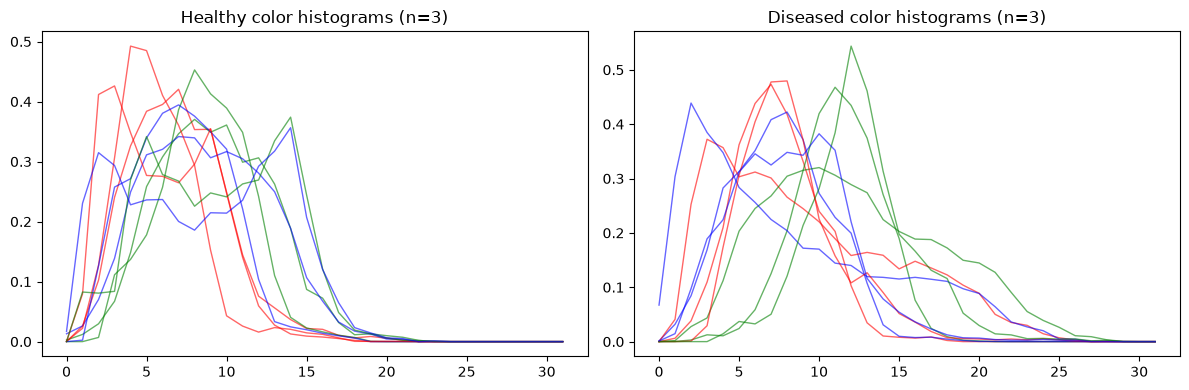

In [78]:
#test color histo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for samples, ax, title, alpha in [(healthy_samples, axes[0], 'Healthy', 0.6), (diseased_samples, axes[1], 'Diseased', 0.6)]:
    for i, s in enumerate(samples):
        hist = color_histogram(s['img'], s['mask'], bins=32)
        r, g, b = hist[:32], hist[32:64], hist[64:96]

        ax.plot(r, color='red', alpha=alpha, linewidth=1)
        ax.plot(g, color='green', alpha=alpha, linewidth=1)
        ax.plot(b, color='blue', alpha=alpha, linewidth=1)

    ax.set_title(f'{title} color histograms (n={len(samples)})')
    
plt.tight_layout()
plt.show()

In [84]:
def color_moments(img, mask):
    #Mean, std, and skewness per channel
    leaf_pixels = img[mask > 0]

    features = []
    for ch in range(3):
        channel = leaf_pixels[:, ch].astype(np.float64)
        mean = channel.mean()
        std = channel.std()
        skew = ((channel - mean) ** 3).mean() / (std ** 3 + 1e-8)
        features.extend([mean, std, skew])
    return np.array(features)

        Healthy_mean  Healthy_std  Diseased_mean  Diseased_std
R_mean         54.10         4.48          70.40          6.26
R_std          23.55         2.35          30.29         10.43
R_skew          0.80         0.31           0.78          0.38
G_mean         76.59         3.08          99.72          4.87
G_std          27.90         4.77          29.68          9.33
G_skew          0.12         0.13           0.24          0.32
B_mean         69.21         5.65          67.75          2.53
B_std          30.82         6.17          33.86         10.73
B_skew          0.19         0.14           0.51          0.21


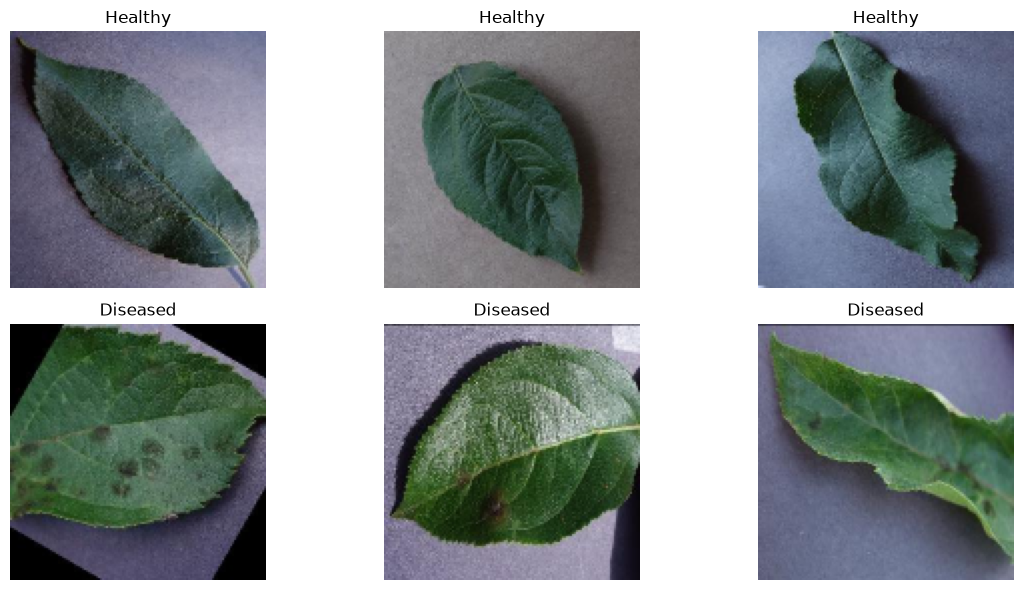

In [85]:
labels = ['R_mean', 'R_std', 'R_skew', 'G_mean', 'G_std', 'G_skew', 'B_mean', 'B_std', 'B_skew']

h_moments = np.array([color_moments(s['img'], s['mask']) for s in healthy_samples])
d_moments = np.array([color_moments(s['img'], s['mask']) for s in diseased_samples])

df_moments = pd.DataFrame({
    'Healthy_mean': h_moments.mean(axis=0), 'Healthy_std': h_moments.std(axis=0),
    'Diseased_mean': d_moments.mean(axis=0), 'Diseased_std': d_moments.std(axis=0),
}, index=labels)
print(df_moments.round(2))

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, s in zip(axes[0], healthy_samples): ax.imshow(s['img']); ax.set_title('Healthy'); ax.axis('off')
for ax, s in zip(axes[1], diseased_samples): ax.imshow(s['img']); ax.set_title('Diseased'); ax.axis('off')

plt.tight_layout()
plt.show()

In [86]:
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

def glcm_features(gray_img, mask):
    #GLCM texture features, averaged over a few distances/angles for rotation
    # to work with mask instead of image we need to crop to bounding box
    ys, xs = np.where(mask > 0)
    if len(ys) == 0:
        return np.zeros(5)
    y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
    cropped = gray_img[y0:y1, x0:x1]

    glcm = graycomatrix(cropped, distances=[1, 3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                         levels=256, symmetric=True, normed=True)
    
    props = ['contrast', 'homogeneity', 'energy', 'correlation', 'dissimilarity']
    return np.array([graycoprops(glcm, p).mean() for p in props])


               Healthy_mean  Diseased_mean
contrast           267.3048       465.2967
homogeneity          0.1275         0.1413
energy               0.0168         0.0337
correlation          0.9023         0.8367
dissimilarity       10.5000        13.0281


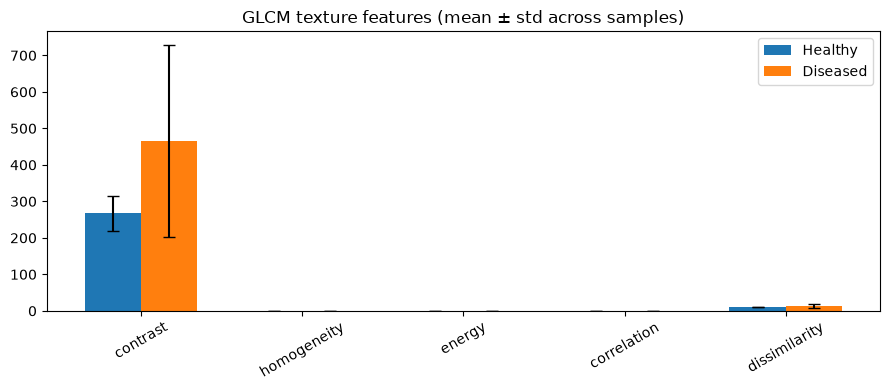

In [87]:
#test glcm
props = ['contrast', 'homogeneity', 'energy', 'correlation', 'dissimilarity']

h_tex = np.array([glcm_features(s['gray'], s['mask']) for s in healthy_samples])
d_tex = np.array([glcm_features(s['gray'], s['mask']) for s in diseased_samples])

df_texture = pd.DataFrame({
    'Healthy_mean': h_tex.mean(axis=0), 'Diseased_mean': d_tex.mean(axis=0),
}, index=props)
print(df_texture.round(4))

x = np.arange(len(props))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(x - width/2, h_tex.mean(axis=0), width, yerr=h_tex.std(axis=0), label='Healthy', capsize=4)
ax.bar(x + width/2, d_tex.mean(axis=0), width, yerr=d_tex.std(axis=0), label='Diseased', capsize=4)
ax.set_xticks(x); ax.set_xticklabels(props, rotation=30); ax.legend()
ax.set_title('GLCM texture features (mean ± std across samples)')

plt.tight_layout()
plt.show()

In [88]:
def lbp_features(gray_img, mask, P=8, R=1):
    #Local Binary Pattern histogram, local texture descriptor
    lbp = local_binary_pattern(gray_img, P, R, method='uniform')
    leaf_lbp_values = lbp[mask > 0]

    hist, _ = np.histogram(leaf_lbp_values, bins=np.arange(0, P + 3), range=(0, P + 2))

    hist = hist.astype(np.float64)
    hist /= (hist.sum() + 1e-8)
    
    return hist


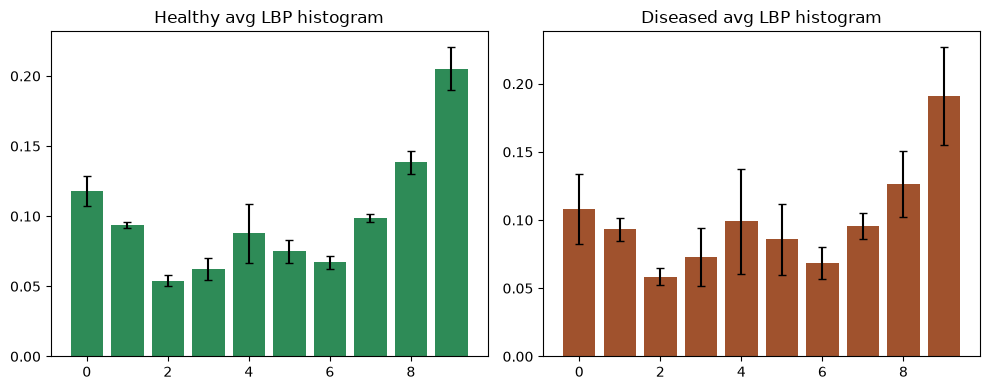

In [89]:
#test lbp
from skimage.feature import local_binary_pattern

h_lbp = np.array([lbp_features(s['gray'], s['mask']) for s in healthy_samples])
d_lbp = np.array([lbp_features(s['gray'], s['mask']) for s in diseased_samples])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bins = range(h_lbp.shape[1])

axes[0].bar(bins, h_lbp.mean(axis=0), yerr=h_lbp.std(axis=0), capsize=3, color='seagreen')
axes[0].set_title('Healthy avg LBP histogram')
axes[1].bar(bins, d_lbp.mean(axis=0), yerr=d_lbp.std(axis=0), capsize=3, color='sienna')
axes[1].set_title('Diseased avg LBP histogram')

plt.tight_layout()
plt.show()

In [90]:
def edge_density(gray_img, mask, t1=40, t2=100):
    #Fraction of edge pixels -- diseased leaves have more irregular structure.
    blurred = cv.GaussianBlur(gray_img, (5, 5), 0)
    edges = cv.Canny(blurred, t1, t2)

    leaf_pixel_count = (mask > 0).sum()
    if leaf_pixel_count == 0:
        return np.array([0.0])
    
    edges_in_leaf = ((edges > 0) & (mask > 0)).sum()
    
    return np.array([edges_in_leaf / leaf_pixel_count])

Healthy edge densities: ['0.1095', '0.1004', '0.1289'] mean: 0.1129
Diseased edge densities: ['0.0980', '0.1770', '0.1172'] mean: 0.1307


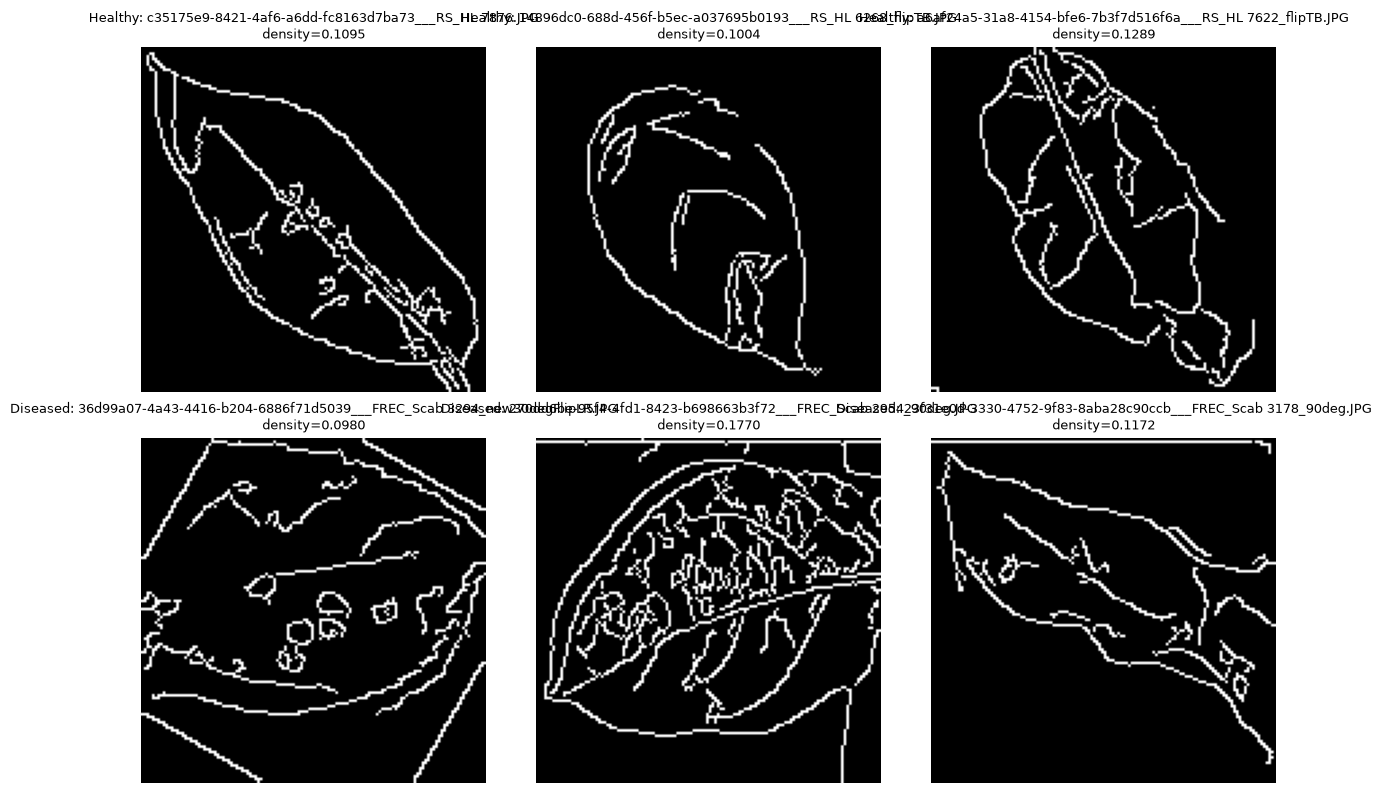

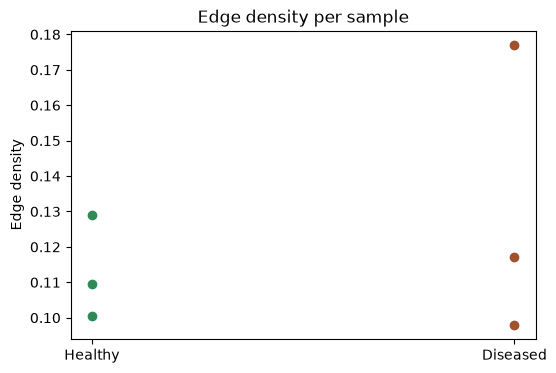

In [91]:
#test edge density
h_edges = [edge_density(s['gray'], s['mask'])[0] for s in healthy_samples]
d_edges = [edge_density(s['gray'], s['mask'])[0] for s in diseased_samples]

print("Healthy edge densities:", [f"{v:.4f}" for v in h_edges], "mean:", f"{np.mean(h_edges):.4f}")
print("Diseased edge densities:", [f"{v:.4f}" for v in d_edges], "mean:", f"{np.mean(d_edges):.4f}")

# view the actual edge maps for each sample
fig, axes = plt.subplots(2, len(healthy_samples), figsize=(4*len(healthy_samples), 8))
for i, s in enumerate(healthy_samples):
    blurred = cv.GaussianBlur(s['gray'], (5, 5), 0)
    edges = cv.Canny(blurred, 40, 100)
    axes[0, i].imshow(edges, cmap='gray')
    axes[0, i].set_title(f"Healthy: {s['fname']}\ndensity={h_edges[i]:.4f}", fontsize=9)
    axes[0, i].axis('off')

for i, s in enumerate(diseased_samples):
    blurred = cv.GaussianBlur(s['gray'], (5, 5), 0)
    edges = cv.Canny(blurred, 40, 100)
    axes[1, i].imshow(edges, cmap='gray')
    axes[1, i].set_title(f"Diseased: {s['fname']}\ndensity={d_edges[i]:.4f}", fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# scatter plot summary
plt.figure(figsize=(6, 4))
plt.scatter(['Healthy']*len(h_edges), h_edges, color='seagreen', label='Healthy')
plt.scatter(['Diseased']*len(d_edges), d_edges, color='sienna', label='Diseased')
plt.ylabel('Edge density')
plt.title('Edge density per sample')
plt.show()

In [92]:
#unified function to extract all the features
IMG_SIZE = (128, 128)  # fixed size 

def extract_features(img_path):
    """
    Returns: Full feature vector for one image: color histogram + color moments + GLCM texture + LBP + edge density.
    Uses the leaf mask from the classical CV step to exclude background pixels.
    """
    img = cv.imread(img_path)
    if img is None:
        return None
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, IMG_SIZE)

    mask = segment_leaf(img)
    if mask.sum() == 0:
        return None
    
    # leaf_only = cv.bitwise_and(img, img, mask=mask)
    gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

    hist = color_histogram(img, mask, bins=32) # 32x3= 96
    moments = color_moments(img, mask) # 3x3 = 9
    texture = glcm_features(gray, mask) # 5 for 5 props
    lbp = lbp_features(gray, mask) # p = 8, 8+2 =10
    edges = edge_density(gray, mask) # 1 

    return np.concatenate([hist, moments, texture, lbp, edges])  # ~121-dim

In [93]:
#test extract features function on sample to make sure all the feartures are extracted correctly
sample_paths = []
for c in [healthy_class, diseased_class]:
    files = os.listdir(os.path.join(TRAIN_DIR, c))[:5]
    sample_paths.extend([os.path.join(TRAIN_DIR, c, f) for f in files])

for p in sample_paths:
    feats = extract_features(p)
    print(f"{os.path.basename(p):30s} -> shape {feats.shape}, any NaN: {np.isnan(feats).any()}")

c35175e9-8421-4af6-a6dd-fc8163d7ba73___RS_HL 7876.JPG -> shape (121,), any NaN: False
14896dc0-688d-456f-b5ec-a037695b0193___RS_HL 6268_flipTB.JPG -> shape (121,), any NaN: False
a6af24a5-31a8-4154-bfe6-7b3f7d516f6a___RS_HL 7622_flipTB.JPG -> shape (121,), any NaN: False
becd7e46-f87c-46d0-a973-f957e99ba4b7___RS_HL 7519_flipTB.JPG -> shape (121,), any NaN: False
d76e79e5-2cd5-4a03-9354-5759b2741210___RS_HL 7980_flipTB.JPG -> shape (121,), any NaN: False
36d99a07-4a43-4416-b204-6886f71d5039___FREC_Scab 3294_new30degFlipLR.JPG -> shape (121,), any NaN: False
270dd6be-95f4-4fd1-8423-b698663b3f72___FREC_Scab 2954_90deg.JPG -> shape (121,), any NaN: False
23f31e0d-3330-4752-9f83-8aba28c90ccb___FREC_Scab 3178_90deg.JPG -> shape (121,), any NaN: False
4b51cc5d-4122-451b-8598-81ea29dc7cd4___FREC_Scab 3290_270deg.JPG -> shape (121,), any NaN: False
fbd09d7f-e816-408a-946e-e4009ec8cae1___FREC_Scab 3289.JPG -> shape (121,), any NaN: False


#### Second: Extract features for the dataset
First sample a subset for sanity check then rerun on full dataset


In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

SAMPLE_PER_CLASS = 300  # e.g. 300 for a quick test run; None = use every image
FEATURES_PATH = os.path.join(OUTPUT_DIR, f"classical_ml_features{'_sample' if SAMPLE_PER_CLASS else ''}.npz")

def build_feature_dataset():
    feature_rows, labels, meta = [], [], []

    for c in classes:
        label = get_label(c)
        class_dir = os.path.join(TRAIN_DIR, c)
        files = os.listdir(class_dir)
        if SAMPLE_PER_CLASS is not None:
            files = files[:SAMPLE_PER_CLASS]

        for f in tqdm(files, desc=c, leave=False):
            feats = extract_features(os.path.join(class_dir, f))
            if feats is None:
                continue
            feature_rows.append(feats)
            labels.append(label)
            meta.append(f"{c}/{f}")

    return np.vstack(feature_rows), np.array(labels), np.array(meta)


if os.path.exists(FEATURES_PATH):
    print("Loading cached features...")
    data = np.load(FEATURES_PATH, allow_pickle=True)
    X, y, meta = data['X'], data['y'], data['meta']
else:
    print("Extracting features (grab a coffee if running the full dataset)...")
    X, y, meta = build_feature_dataset()
    np.savez_compressed(FEATURES_PATH, X=X, y=y, meta=meta)
    print(f"Saved features to {FEATURES_PATH}")

print(f"Feature matrix shape: {X.shape}")
print(pd.Series(y).value_counts())

Extracting features (grab a coffee if running the full dataset)...


Saved features to outputs/classical_ml_features_sample.npz
Feature matrix shape: (11400, 121)
diseased    7800
healthy     3600
Name: count, dtype: int64


### Step 3: Deep Learning